ensemble explainable approcach to brain tumor detection from MRI images 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import psutil
from torchviz import make_dot  
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Augmentation Pipeline
transform = {
    'train': transforms.Compose([
        transforms.Resize(256),               
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),  
        transforms.ColorJitter(brightness=0.1, contrast=0.1),  
        transforms.RandomHorizontalFlip(p=0.5),  
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}


data_dir = r"C:\Users\bhuva\Desktop\brain_CT\split_data" 
batch_size = 16
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform['train'])
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform['val'])
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform['val'])


# Data Loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



In [ ]:

# Densenet-121
model = models.densenet121(weights="IMAGENET1K_V1")

in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features, 4)  # number of classes
)


In [ ]:


model = model.to(device)



# Hyper parameters
num_epochs = 10
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-5
weight_decay = 1e-5
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
early_stopping_patience = 3



c:\Users\bhuva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# logging for metrics
train_log = []
best_val_loss = np.inf
patience_counter = 0

# Training loop 
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    epoch_start_time = time.time()
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = 0.0, 0.0

    # Validation
    model.eval()
    with torch.no_grad():
        correct, total = 0, 0
        val_running_loss = 0.0
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        val_loss = val_running_loss / total
        val_acc = correct / total

    scheduler.step(val_loss)

    # logging
    epoch_time = time.time() - epoch_start_time
    mem_usage = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)  # Memory in MB
    train_log.append({
        'epoch': epoch + 1, 'train_loss': train_loss, 'train_acc': train_acc, 
        'val_loss': val_loss, 'val_acc': val_acc, 'epoch_time': epoch_time, 'memory_usage_mb': mem_usage
    })

    # Early stopping 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'dense_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Time: {epoch_time:.2f}s")

# Save to CSV
pd.DataFrame(train_log).to_csv("training_log_brain_dense.csv", index=False)



Epoch 1/10: 100%|██████████| 352/352 [02:14<00:00,  2.63batch/s]


Epoch 1/10 - Train Loss: 0.8710, Train Acc: 0.6616, Val Loss: 0.4539, Val Acc: 0.8873, Time: 140.80s


Epoch 2/10: 100%|██████████| 352/352 [02:11<00:00,  2.67batch/s]


Epoch 2/10 - Train Loss: 0.4181, Train Acc: 0.8617, Val Loss: 0.2425, Val Acc: 0.9444, Time: 139.10s


Epoch 3/10: 100%|██████████| 352/352 [02:12<00:00,  2.66batch/s]


...

Epoch 8/10 - Train Loss: 0.1199, Train Acc: 0.9651, Val Loss: 0.0774, Val Acc: 0.9700, Time: 142.45s


Epoch 9/10: 100%|██████████| 352/352 [02:11<00:00,  2.68batch/s]


Epoch 9/10 - Train Loss: 0.0875, Train Acc: 0.9783, Val Loss: 0.0763, Val Acc: 0.9700, Time: 137.90s


Epoch 10/10: 100%|██████████| 352/352 [02:10<00:00,  2.70batch/s]


Epoch 10/10 - Train Loss: 0.0900, Train Acc: 0.9735, Val Loss: 0.0813, Val Acc: 0.9772, Time: 137.31s


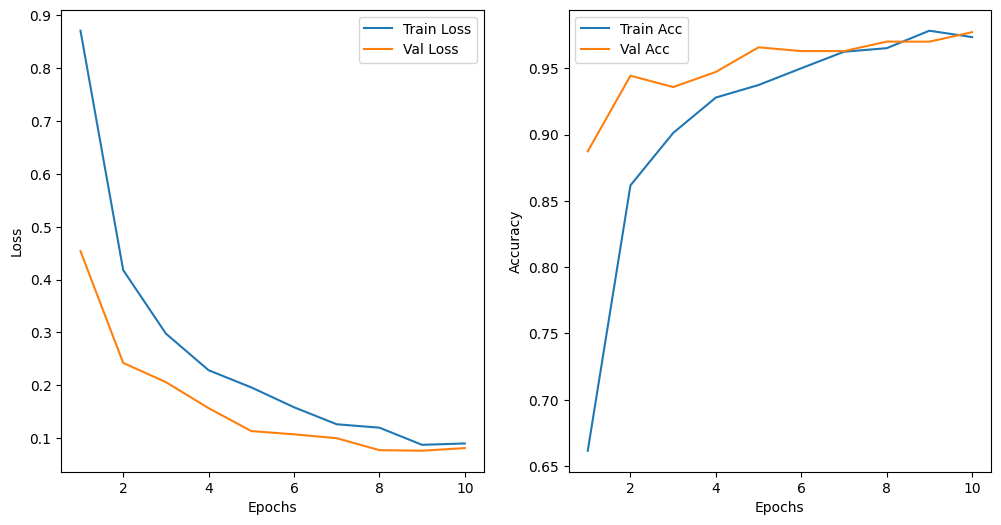

In [ ]:
# Loss and accuracy plot
history_df = pd.DataFrame(train_log)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc')
plt.plot(history_df['epoch'], history_df['val_acc'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()





C:\Users\bhuva\AppData\Local\Temp\ipykernel_32248\3713617312.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dense_model.pth'))


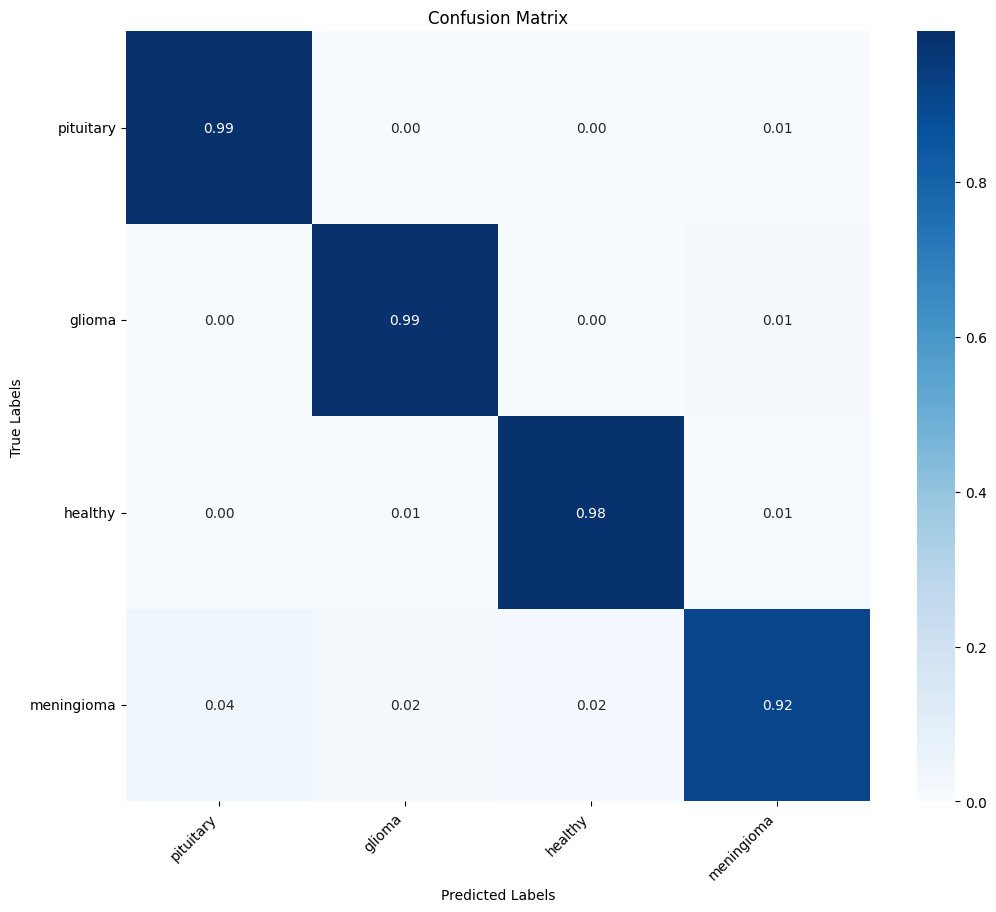

In [ ]:

model.load_state_dict(torch.load('dense_model.pth'))
model.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Confusion Matrix 
class_names = ["glioma", "healthy", "meningioma", "pituitary"]
def plot_confusion_matrix(y_true, y_pred, classes, normalize=True, top_n=None):
    cm = confusion_matrix(y_true, y_pred)
    if top_n:
        misclassified_counts = np.sum(cm, axis=1) - np.diag(cm)
        top_confused_indices = np.argsort(misclassified_counts)[-top_n:]
        cm = cm[top_confused_indices, :][:, top_confused_indices]
        classes = [classes[i] for i in top_confused_indices]
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

plot_confusion_matrix(all_labels, all_preds, classes=class_names, normalize=True, top_n=10)

Predicted Class: pituitary with Probability: 0.7575


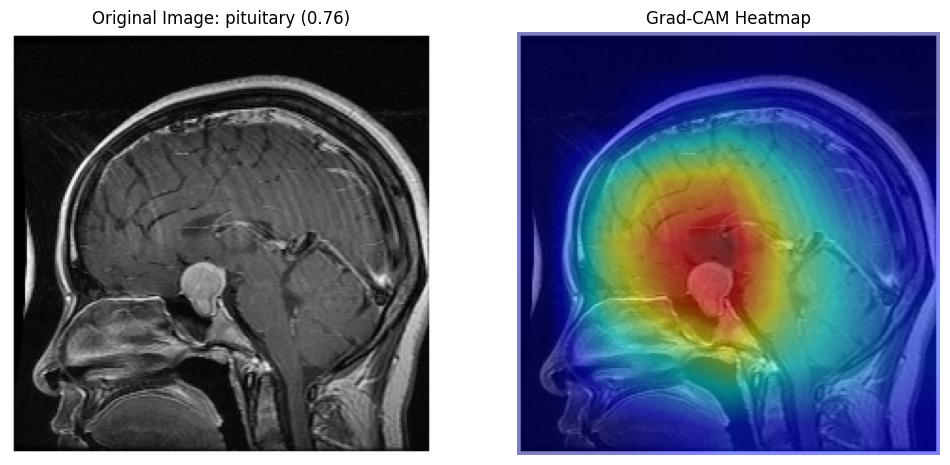

Confidence Score: 0.7575


In [ ]:
import cv2

# target layer for Grad-CAM 
target_layer = model.features[-1]

# Grad-CAM
cam = GradCAM(model=model, target_layers=[target_layer])

# Class names
classes = ["glioma", "healthy", "meningioma", "pituitary"]


def classify_and_visualize(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (224, 224))  # Resize 
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  #  BGR to RGB

    img_tensor = preprocess_image(img_rgb, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).to(device)

    # inference
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        predicted_idx = probs.argmax(dim=1).item()
        predicted_class = classes[predicted_idx]
        predicted_prob = probs[0, predicted_idx].item()

    # Grad-CAM heatmap generation
    grayscale_cam = cam(input_tensor=img_tensor)[0]  
    cam_image = show_cam_on_image(img_rgb / 255.0, grayscale_cam, use_rgb=True)

    print(f"Predicted Class: {predicted_class} with Probability: {predicted_prob:.4f}")

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Original Image: {predicted_class} ({predicted_prob:.2f})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")
    plt.show()


    def model_forward(x):
        with torch.no_grad():
            x = x.to(device)
            return model(x)

 
    print(f"Confidence Score: {predicted_prob:.4f}")
classify_and_visualize(r"C:\Users\bhuva\Downloads\OL-08-02-0781-g01.jpg")

del cam
